In [1]:
# %matplotlib inline

import os
import sys


import torch
import numpy as np
import matplotlib.pyplot as plt

# Local imports
from data.load import ParallelMelspecDataset, collate_fn
from kenku.modules import KameBlock
from kenku.network import KenkuTeacher, stack_frames, unstack_frames

from typing import Union, List, Tuple, Optional

from torch import nn, Tensor
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

from tqdm import tqdm

torch.set_default_device("cuda:0")

ModuleNotFoundError: No module named 'data'

In [ ]:
rng = np.random.default_rng(42)
epochs = 5
batch_size = 20
lrate = 5e-5
sf = 4
in_ch = 80 * sf
conv_ch = 80 * sf
att_ch = 80 * sf
out_ch = 80 * sf
embed_ch = 2
num_accents = 2
_w_da_init = 0
w_da_decay = 4 / epochs

# writer = SummaryWriter("./tboard_logs/training")

dataset = ParallelMelspecDataset(melspec_dir = "../../Data/processed/VCTK/melspec", 
                                 transcript_dir = "../../Data/processed/VCTK/transcript_standardized",
                                 speaker_info_path = "../../Data/processed/VCTK/speaker_info.csv",
                                 min_samples_per_sentence = 10,
                                 sample_pairing = 'product',
                                 rng = rng)
dataset.preload_melspecs()

class KenkuDataLoader(DataLoader):
  def __init__(self, *args, callback_fn = None, **kwargs):
    super(KenkuDataLoader, self).__init__(*args, **kwargs)
    self.callback_fn = callback_fn if callback_fn else lambda *args, **kwargs: None

  def __next__(self, *args, **kwargs):
    self.callback_fn()
    super(KenkuDataLoader, self).__next__(*args, **kwargs)

 
loader = DataLoader(
  dataset, 
  batch_size=batch_size,
  shuffle=True,
  num_workers=0,  # Set to 0 or os.cpu_count() depending on the environment
  drop_last=True,
  collate_fn=collate_fn,
  generator=torch.Generator(device='cuda').manual_seed(42),
)

for batch in loader:
  break

model = KenkuTeacher(in_ch, conv_ch, att_ch, out_ch, embed_ch, num_accents)

optimizer = torch.optim.Adam(model.parameters(), lr=lrate, betas=(0.9, 0.999))

In [ ]:
# checkpoint = torch.load('./checkpoints/test_model_ep3.pt', weights_only=True)

# model.load_state_dict(checkpoint['model'])

# optimizer.load_state_dict(checkpoint['optimizer'])

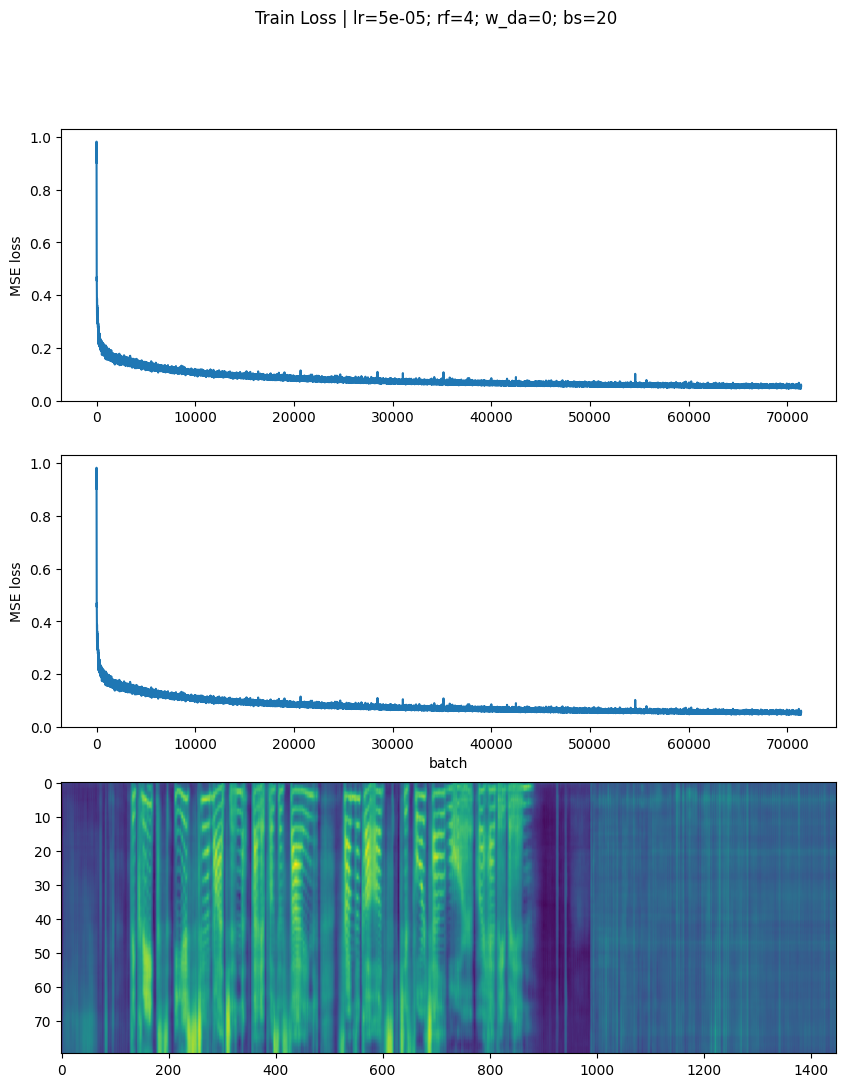

  0%|          | 27/20752 [00:15<3:21:02,  1.72it/s]


KeyboardInterrupt: 

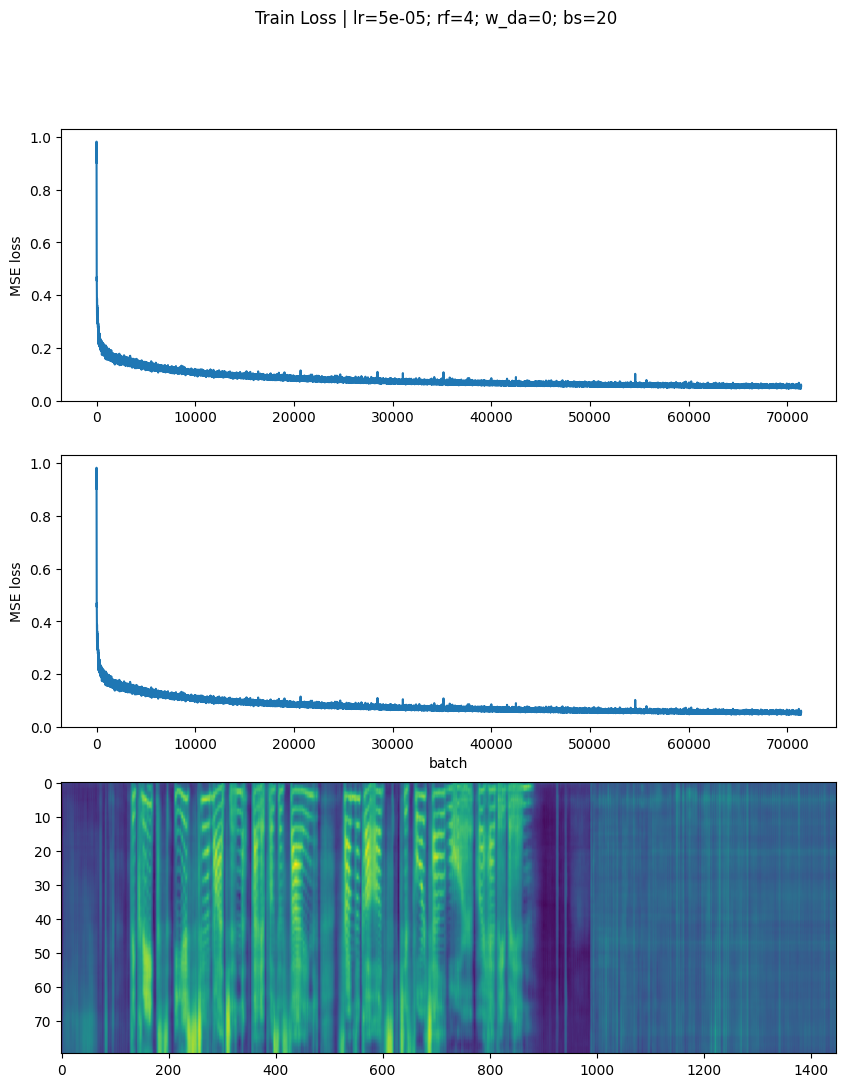

In [ ]:
from IPython.display import display, clear_output

# losses = []
epoch_markers = []

w_da_init = _w_da_init

for i in range(4):
  w_da = w_da_init * np.exp(-i * w_da_decay)

save_every = 100
plot_every = 20

imshow_batch = next(iter(loader))
maxlen_idx = np.argmax([torch.sum(mask).item() for mask in list(imshow_batch[3])])
src_mel, tgt_mel, _, _, src_info, tgt_info = [x[maxlen_idx] for x in imshow_batch]

fig, axes = plt.subplots(3, 1, figsize=(10, 12))
fig.suptitle(f'Train Loss | lr={lrate}; sf={sf}; w_da={_w_da_init}; bs={batch_size}')

for epoch in range(epochs):
  print(f"===== Epoch {epoch} =====")
  
  # w_da = w_da_init * np.exp(-epoch * w_da_decay)
  
  for bi, batch in tqdm(enumerate(loader), total=len(dataset) // batch_size):
  # for bi, batch in enumerate(loader):
    model.clear_paddings()
    mse_loss, da_loss, att_np = model.calc_loss(*batch, stack_factor=sf)
    loss = mse_loss + w_da * da_loss
    model.clear_paddings()
    loss_val = loss.item()
    losses.append(loss_val)
    
    model.zero_grad()
    loss.backward()
    optimizer.step()
    
    if bi > 0 and bi % plot_every == 0:
      [ax.clear() for ax in axes]
      axes[0].set(ylabel = 'MSE loss')
      axes[1].set(xlabel = 'batch',
                  ylabel = 'MSE loss')

      # Plot training loss
      axes[0].plot(range(len(losses)), losses, label='training loss')
      zoom_xstart = [0, *epoch_markers][-1]
      axes[1].plot(range(len(losses) - zoom_xstart), losses[zoom_xstart:])

      # Mark epoch lines
      for em in epoch_markers:
          axes[0].axvline(em, linestyle='--', color='k', linewidth=0.5)


      # Generate prediction and plot spectrogram
      model.clear_paddings()
      pred_mel = unstack_frames(model(stack_frames(src_mel.unsqueeze(0), sf), 
                                      stack_frames(tgt_mel.unsqueeze(0), sf), 
                                      src_info, 
                                      tgt_info)[0], sf).squeeze(0).cpu().detach().numpy()
      
      # Now update imshow (important to do after displaying `fig`)
      axes[2].imshow(pred_mel, aspect='auto')
      fig.canvas.draw()  # Force Jupyter to refresh the figure
      
      # fig.canvas.flush_events()
      
      
      # Display the figure update
      clear_output(wait=True)  # Clear previous output
      display(fig)             # Display the figure
      
      
      # writer.add_scalar("Loss/train", loss_val, bi + epoch * len(loader))

      # # Log spectrogram as an image
      # writer.add_image("Mel Spectrogram", pred_mel, bi + epoch * len(loader), dataformats='HW')

  
    if bi > 0  and bi % save_every == 0 or bi == (len(dataset) // batch_size) - 1:
      torch.save({"model": model.state_dict(),
                  "optimizer": optimizer.state_dict()}, 
                 f'./checkpoints/test_model_ep{epoch}.pt')
      
      with open(f'./checkpoints/losses_ep{epoch}.txt', 'w') as file:
        file.write(str(list(losses)))
  
  epoch_markers.append(len(losses))
    

In [ ]:
# model.clear_paddings()

# batch = next(iter(loader))

# print(len(batch))
# src_mel, tgt_mel, _, _, src_info, tgt_info = [x[0] for x in batch]

# [print(x.shape) for x in [stack_frames(src_mel.unsqueeze(0), sf), stack_frames(tgt_mel.unsqueeze(0), sf)]]

# pred_mel = unstack_frames(model(stack_frames(src_mel.unsqueeze(0), sf), 
#                                 stack_frames(tgt_mel.unsqueeze(0), sf), 
#                                 src_info, 
#                                 tgt_info), sf).squeeze(0)

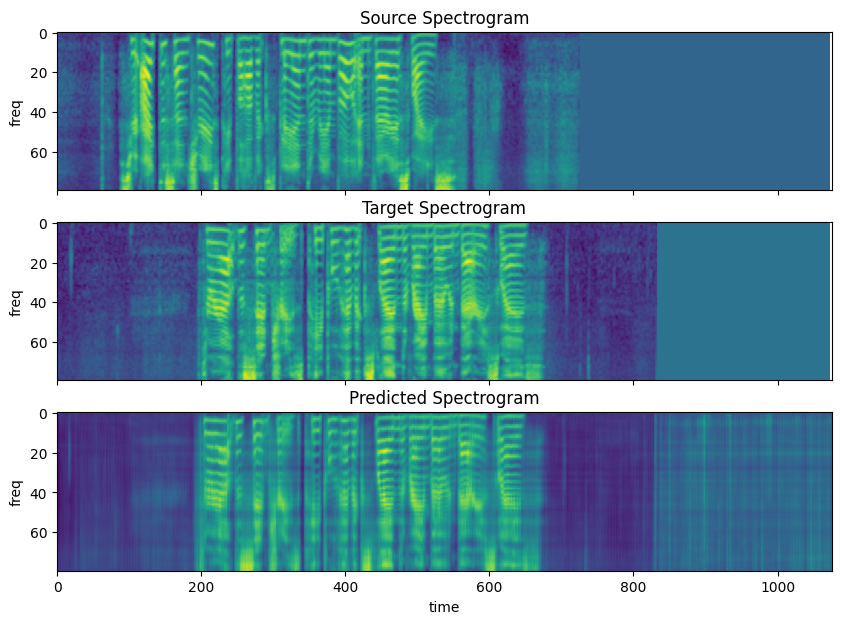

In [ ]:
model.clear_paddings()

src_mel, tgt_mel, _, _, src_info, tgt_info = [x[0] for x in next(iter(loader))]

pred_mel = unstack_frames(model(stack_frames(src_mel.unsqueeze(0), sf), 
                                stack_frames(tgt_mel.unsqueeze(0), sf), 
                                src_info, 
                                tgt_info)[0], sf).squeeze(0)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

for ax, mel, title in zip(axes, [src_mel, tgt_mel, pred_mel], ['Source Spectrogram', 'Target Spectrogram', 'Predicted Spectrogram',]):
  ax.set(ylabel='freq', title=title)
  ax.imshow(mel.cpu().detach().numpy(), aspect='auto')
ax.set_xlabel('time')
plt.show()

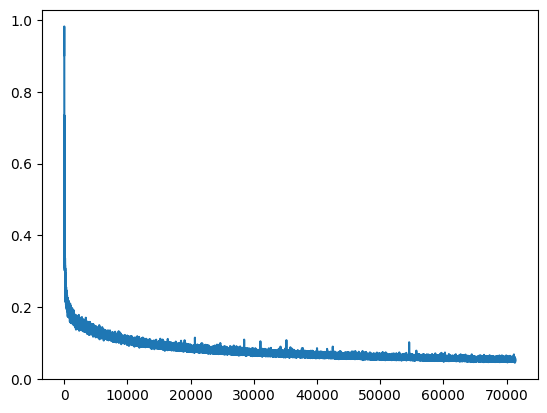

In [11]:
import matplotlib.pyplot as plt

losses = []
with open('./checkpoints/losses_ep3.txt' ,'r') as file:
  losses  = list(map(float, file.readline()[1:-2].split(', ')))
  
plt.plot(range(len(losses)), losses)

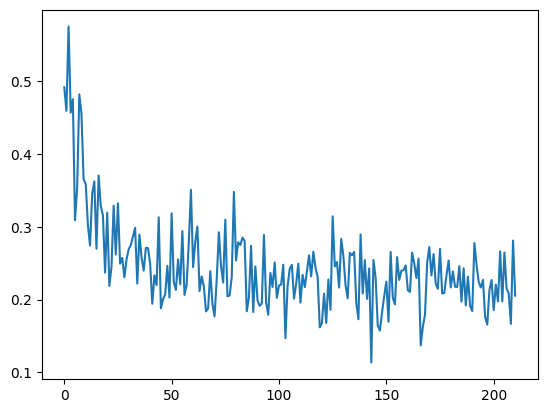

In [ ]:
# import matplotlib.pyplot as plt

# losses = []
# with open('./checkpoints/losses_ep0.txt' ,'r') as file:
#   losses  = list(map(float, file.readline()[1:-2].split(', ')))
  
# plt.plot(range(len(losses)), losses)